<a href="https://colab.research.google.com/github/Ana-INCH/ApiDesigualdadSalarial/blob/main/brecha_salarial_genero_mexico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brecha salarial de género en México

Proyecto final: Análisis de la brecha salarial de género y su relación con la participación laboral, usando datos de la OCDE y el Banco Mundial.

## 1. Planteamiento del problema

A pesar de los avances legales en materia de igualdad, en México sigue existiendo una diferencia entre lo que ganan hombres y mujeres. Quiero ver qué tan grande es esa diferencia, cómo ha cambiado en los últimos 20 años, y si tiene relación con cuántas mujeres participan en el mercado laboral.

**Por qué elegí este tema:** me parece un problema medible y con datos oficiales disponibles, a diferencia de otros temas de género donde la información es más escasa o menos comparable entre países.

**Objetivos:**
- Descargar la serie histórica de brecha salarial en México desde la OCDE.
- Compararla contra la participación laboral por sexo (Banco Mundial).
- Ver si ambas cosas se mueven juntas o son independientes.

**Hipótesis:**
- H1: la brecha salarial no ha bajado de forma sostenida en los últimos 20 años.
- H2: la brecha de participación laboral entre hombres y mujeres se mantiene sin importar lo que pase con el salario.

## 2. Preguntas que quiero responder

1. ¿Cómo ha cambiado la brecha salarial en México desde 2000?
2. ¿Cuál fue el año con más brecha y cuál con menos?
3. ¿Qué tan distinta es la participación laboral de hombres vs mujeres?
4. ¿La brecha salarial y la brecha de participación se comportan parecido?
5. ¿Qué tan completa es la información que tengo (faltan años)?



## 3. De dónde vienen los datos

Usé dos fuentes:

- **OCDE** (`sdmx.oecd.org`): Trae la brecha salarial de género calculada como mediana, que es el indicador que normalmente se reporta y compara entre países.
- **Banco Mundial** (`api.worldbank.org`): Participación laboral por sexo, para tener contexto de cuántas mujeres realmente trabajan, no solo cuánto ganan las que ya trabajan.

Elegí estas dos porque son organismos internacionales con metodología estandarizada, así que los datos son comparables entre países y se actualizan periódicamente. No necesité hacer scraping, ambas exponen API pública.

No hay ningún tema de privacidad aquí, son datos agregados por país y año, no de personas individuales.

Para organizar la consulta uso un diccionario con los indicadores del Banco Mundial y una tupla con el país (para no arriesgarme a modificarlo por accidente en el código).


In [7]:
# indicadores que voy a consultar en el Banco Mundial
INDICADORES_WORLD_BANK = {
    'SL.TLF.CACT.FE.ZS': 'Participación laboral femenina (%)',
    'SL.TLF.CACT.MA.ZS': 'Participación laboral masculina (%)',
}

PAIS_OBJETIVO = ('MEX', 'Mexico')  # tupla porque no debería cambiar durante la ejecución

for codigo, descripcion in INDICADORES_WORLD_BANK.items():
    print(codigo, '->', descripcion)

SL.TLF.CACT.FE.ZS -> Participación laboral femenina (%)
SL.TLF.CACT.MA.ZS -> Participación laboral masculina (%)


In [2]:
!pip install requests pandas matplotlib numpy seaborn scipy scikit-learn plotly nltk wordcloud -q

import re
import requests
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 4. Consultando la API de la OCDE

Dataset: `Gender wage gap` (`https://data-explorer.oecd.org/s/499`).

El primer intento de filtrar directo por país en la URL me dio error 404 varias veces porque el número de versión del dataset cambia y el orden de las dimensiones no es obvio. Terminé resolviéndolo pidiendo el dataset completo (todos los países) y filtrando después con pandas, que es más lento pero no depende de adivinar la estructura exacta de la consulta.


In [3]:
def consultar_oecd_gender_wage_gap(pais_codigo='MEX', anio_inicio=2000):
    """
    Trae la brecha salarial de género de la OCDE para un país.

    Pide todo el dataset (no se puede filtrar país directo en la URL sin
    arriesgarse a un 404 por versión/dimensiones), filtra por REF_AREA y
    se queda con la serie "Median", que es el indicador oficial que reporta
    la OCDE (también existen Mean, Decile 1 y Decile 9, pero no los uso aquí).
    """
    url = 'https://sdmx.oecd.org/public/rest/data/OECD.ELS.SAE,DSD_EARNINGS@GENDER_WAGE_GAP,/all'
    parametros = {
        'startPeriod': anio_inicio,
        'dimensionAtObservation': 'AllDimensions',
        'format': 'csvfilewithlabels'
    }

    try:
        respuesta = requests.get(url, params=parametros, timeout=30)
        respuesta.raise_for_status()

        todos_los_paises = pd.read_csv(io.StringIO(respuesta.text))
        if todos_los_paises.empty:
            print('la OCDE respondió vacío')
            return None

        print(f'{len(todos_los_paises)} filas descargadas (todos los países)')

        mediana_todos = todos_los_paises[todos_los_paises['Aggregation operation'] == 'Median'].copy()
        cols_rename = {
            'TIME_PERIOD': 'anio',
            'OBS_VALUE': 'brecha_salarial_pct',
            'REF_AREA': 'pais',
        }
        if 'Reference area' in mediana_todos.columns:
            cols_rename['Reference area'] = 'pais_nombre'
        mediana_todos = mediana_todos.rename(columns=cols_rename)
        keep = [c for c in ['pais', 'pais_nombre', 'anio', 'brecha_salarial_pct'] if c in mediana_todos.columns]
        df_oecd_all = mediana_todos[keep].dropna(subset=['brecha_salarial_pct']).copy()
        df_oecd_all['anio'] = df_oecd_all['anio'].astype(int)
        df_oecd_all = df_oecd_all.sort_values(['pais', 'anio']).reset_index(drop=True)

        solo_pais = todos_los_paises[todos_los_paises['REF_AREA'] == pais_codigo]
        if solo_pais.empty:
            print(f'no hay filas para {pais_codigo}')
            return None

        solo_mediana = solo_pais[solo_pais['Aggregation operation'] == 'Median']
        if solo_mediana.empty:
            print('no se encontró la serie Median para este país')
            return None

        tabla = solo_mediana[['TIME_PERIOD', 'OBS_VALUE']].rename(
            columns={'TIME_PERIOD': 'anio', 'OBS_VALUE': 'brecha_salarial_pct'}
        ).sort_values('anio').reset_index(drop=True)

        print(f'{len(tabla)} filas para {pais_codigo}')
        return tabla, df_oecd_all

    except requests.exceptions.HTTPError as e:
        print('error HTTP en la consulta a la OCDE:', e)
        return None
    except requests.exceptions.RequestException as e:
        print('error de conexión con la OCDE:', e)
        return None
    except pd.errors.ParserError as e:
        print('la respuesta no vino en CSV válido:', e)
        return None


consulta = consultar_oecd_gender_wage_gap(pais_codigo=PAIS_OBJETIVO[0], anio_inicio=2000)
if consulta is None:
    df_oecd, df_oecd_all = None, None
else:
    df_oecd, df_oecd_all = consulta
df_oecd

3132 filas descargadas (todos los países)
18 filas para MEX


,anio,brecha_salarial_pct
0,2005,16.666667
1,2006,18.604651
2,2007,12.500000
3,2008,22.222222
4,2009,16.666667
5,2010,11.627907
6,2011,10.000000
7,2012,13.555556
8,2013,15.433404
9,2014,18.300000


## 5. Participación laboral (Banco Mundial)

Aquí sí pude automatizar directo con un `for` sobre el diccionario de indicadores, sin el problema de dimensiones que tuvo la OCDE.


In [8]:
def consultar_world_bank(pais='MEX', indicador='SL.TLF.CACT.FE.ZS'):
    """Trae un indicador del Banco Mundial para un país. Devuelve [anio, valor]."""
    url = f'https://api.worldbank.org/v2/country/{pais}/indicator/{indicador}'
    parametros = {'format': 'json', 'per_page': 200}

    try:
        respuesta = requests.get(url, params=parametros, timeout=15)
        respuesta.raise_for_status()
        datos = respuesta.json()

        if len(datos) < 2 or not datos[1]:
            print(f'  sin datos para {indicador}')
            return None

        tabla = pd.DataFrame(datos[1])[['date', 'value']].rename(columns={'date': 'anio', 'value': 'valor'})
        tabla['anio'] = tabla['anio'].astype(int)
        tabla = tabla.dropna(subset=['valor']).sort_values('anio').reset_index(drop=True)
        return tabla

    except requests.exceptions.RequestException as e:
        print(f'  error de conexión ({indicador}):', e)
        return None


resultados_wb = {}
for codigo, descripcion in INDICADORES_WORLD_BANK.items():
    print('descargando:', descripcion)
    tabla = consultar_world_bank(pais=PAIS_OBJETIVO[0], indicador=codigo)
    if tabla is not None:
        resultados_wb[codigo] = tabla

df_wb_mujeres = resultados_wb.get('SL.TLF.CACT.FE.ZS')
df_wb_hombres = resultados_wb.get('SL.TLF.CACT.MA.ZS')

df_wb_mujeres.tail(10)

descargando: Participación laboral femenina (%)
descargando: Participación laboral masculina (%)


,anio,valor
26,2016,43.988
27,2017,43.627
28,2018,44.134
29,2019,45.573
30,2020,41.704
31,2021,44.615
32,2022,46.004
33,2023,47.317
34,2024,47.414
35,2025,47.450


Uno los dos indicadores del Banco Mundial en una sola tabla, por año.

In [9]:
df_participacion = df_wb_mujeres.merge(
    df_wb_hombres, on='anio', suffixes=('_mujeres', '_hombres')
).rename(columns={'valor_mujeres': 'participacion_mujeres', 'valor_hombres': 'participacion_hombres'})

df_participacion.tail(10)

,anio,participacion_mujeres,participacion_hombres
26,2016,43.988,78.273
27,2017,43.627,78.237
28,2018,44.134,78.165
29,2019,45.573,78.057
30,2020,41.704,72.492
31,2021,44.615,76.673
32,2022,46.004,77.314
33,2023,47.317,77.551
34,2024,47.414,77.215
35,2025,47.450,77.113


## 6. Explorando los datos antes de seguir

Antes de sacar conclusiones reviso tamaño, tipos de dato y si hay nulos o duplicados en ambas tablas.


In [10]:
print('--- brecha salarial (OCDE) ---')
print('filas:', df_oecd.shape[0], '| columnas:', df_oecd.shape[1])
df_oecd.info()
print()
df_oecd.describe()

--- brecha salarial (OCDE) ---
filas: 18 | columnas: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   anio                 18 non-null     int64  
 1   brecha_salarial_pct  18 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 420.0 bytes



,anio,brecha_salarial_pct
count,18.000000,18.000000
mean,2014.000000,15.260024
std,6.087596,3.050664
min,2005.000000,10.000000
25%,2009.250000,12.763889
50%,2013.500000,15.962826
75%,2017.750000,16.666667
max,2025.000000,22.222222


In [11]:
print('nulos por columna:')
print(df_oecd.isnull().sum())
print('duplicados:', df_oecd.duplicated().sum())

nulos por columna:
anio                   0
brecha_salarial_pct    0
dtype: int64
duplicados: 0


In [12]:
print('--- participación laboral (Banco Mundial) ---')
print('filas:', df_participacion.shape[0], '| columnas:', df_participacion.shape[1])
df_participacion.info()
print()
df_participacion.describe()

--- participación laboral (Banco Mundial) ---
filas: 36 | columnas: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   anio                   36 non-null     int64  
 1   participacion_mujeres  36 non-null     float64
 2   participacion_hombres  36 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 996.0 bytes



,anio,participacion_mujeres,participacion_hombres
count,36.000000,36.000000,36.000000
mean,2007.500000,41.364528,80.226972
std,10.535654,3.782199,2.727322
min,1990.000000,33.981000,72.492000
25%,1998.750000,38.473750,78.264000
50%,2007.500000,42.451000,80.258000
75%,2016.250000,44.024500,82.775750
max,2025.000000,47.450000,84.496000


In [13]:
print('nulos por columna:')
print(df_participacion.isnull().sum())
print('duplicados:', df_participacion.duplicated().sum())

nulos por columna:
anio                     0
participacion_mujeres    0
participacion_hombres    0
dtype: int64
duplicados: 0


Un vistazo rápido antes de entrar más a fondo:

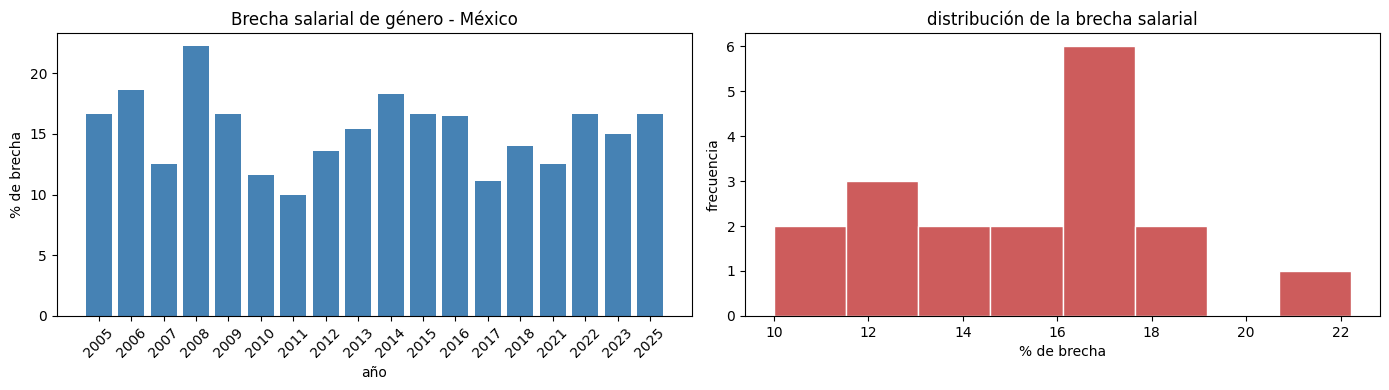

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(df_oecd['anio'].astype(str), df_oecd['brecha_salarial_pct'], color='steelblue')
axes[0].set_title('Brecha salarial de género - México')
axes[0].set_xlabel('año')
axes[0].set_ylabel('% de brecha')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(df_oecd['brecha_salarial_pct'], bins=8, color='indianred', edgecolor='white')
axes[1].set_title('distribución de la brecha salarial')
axes[1].set_xlabel('% de brecha')
axes[1].set_ylabel('frecuencia')

plt.tight_layout()
plt.show()

## 7. Revisando huecos en la serie de tiempo

La OCDE no publica el dato todos los años, así que reviso cuáles faltan en vez de asumir que la serie es continua. No voy a rellenar esos huecos con un promedio ni nada parecido, porque inventar una brecha salarial para un año sin encuesta sería mentir con los datos mejor dejar el hueco documentado.


In [14]:
anio_min, anio_max = df_oecd['anio'].min(), df_oecd['anio'].max()
anios_esperados = set(range(anio_min, anio_max + 1))
anios_con_dato = set(df_oecd['anio'])
faltantes = sorted(anios_esperados - anios_con_dato)

print(f'rango: {anio_min}-{anio_max}')
print(f'años con dato: {len(anios_con_dato)} de {len(anios_esperados)}')
print('años sin dato:', faltantes if faltantes else 'ninguno')

rango: 2005-2025
años con dato: 18 de 21
años sin dato: [2019, 2020, 2024]


## 8. Selección de datos con .loc y .iloc

In [15]:
# .loc: selección por condición
brecha_reciente = df_oecd.loc[df_oecd['anio'] >= 2020, ['anio', 'brecha_salarial_pct']]
brecha_reciente

,anio,brecha_salarial_pct
14,2021,12.500000
15,2022,16.666667
16,2023,15.000000
17,2025,16.666667


In [16]:
# .iloc: selección por posición
df_oecd.iloc[0:3]

,anio,brecha_salarial_pct
0,2005,16.666667
1,2006,18.604651
2,2007,12.500000


## 9. Columnas nuevas y estadísticas

Agrego una columna que clasifica cada año como brecha alta/baja respecto a la mediana histórica, y un z-score para ver qué tan lejos está cada año del promedio.


In [17]:
mediana_hist = df_oecd['brecha_salarial_pct'].median()
media_hist = df_oecd['brecha_salarial_pct'].mean()
desv_hist = df_oecd['brecha_salarial_pct'].std()

df_oecd['nivel_brecha'] = df_oecd['brecha_salarial_pct'].apply(
    lambda x: 'alta' if x > mediana_hist else 'baja'
)
df_oecd['z_score'] = np.round((df_oecd['brecha_salarial_pct'] - media_hist) / desv_hist, 2)
df_oecd['decada'] = ((df_oecd['anio'] // 10) * 10).astype(str) + 's'

df_oecd

,anio,brecha_salarial_pct,nivel_brecha,z_score,decada
0,2005,16.666667,alta,0.46,2000s
1,2006,18.604651,alta,1.10,2000s
2,2007,12.500000,baja,-0.90,2000s
3,2008,22.222222,alta,2.28,2000s
4,2009,16.666667,alta,0.46,2000s
5,2010,11.627907,baja,-1.19,2010s
6,2011,10.000000,baja,-1.72,2010s
7,2012,13.555556,baja,-0.56,2010s
8,2013,15.433404,baja,0.06,2010s
9,2014,18.300000,alta,1.00,2010s


In [18]:
print(f'promedio:  {df_oecd["brecha_salarial_pct"].mean():.2f}%')
print(f'mediana:   {df_oecd["brecha_salarial_pct"].median():.2f}%')
print(f'mínimo:    {df_oecd["brecha_salarial_pct"].min():.2f}% (año {df_oecd.loc[df_oecd["brecha_salarial_pct"].idxmin(), "anio"]})')
print(f'máximo:    {df_oecd["brecha_salarial_pct"].max():.2f}% (año {df_oecd.loc[df_oecd["brecha_salarial_pct"].idxmax(), "anio"]})')
print(f'desv est:  {df_oecd["brecha_salarial_pct"].std():.2f}')

promedio:  15.26%
mediana:   15.96%
mínimo:    10.00% (año 2011)
máximo:    22.22% (año 2008)
desv est:  3.05


In [19]:
# checar que no haya quedado ningún NaN antes de dar por cerrada la limpieza
print('nulos en df_oecd:', df_oecd.isnull().values.any())
print('nulos en df_participacion:', df_participacion.isnull().values.any())

nulos en df_oecd: False
nulos en df_participacion: False


## 10. Brecha salarial vs. participación laboral

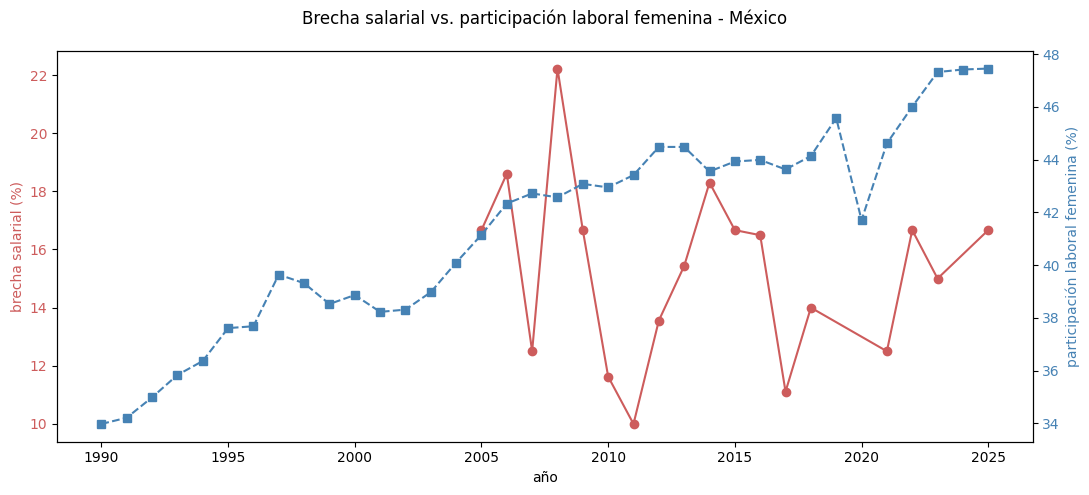

In [20]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(df_oecd['anio'], df_oecd['brecha_salarial_pct'], color='indianred', marker='o', label='brecha salarial (%)')
ax1.set_xlabel('año')
ax1.set_ylabel('brecha salarial (%)', color='indianred')
ax1.tick_params(axis='y', labelcolor='indianred')

ax2 = ax1.twinx()
ax2.plot(df_participacion['anio'], df_participacion['participacion_mujeres'],
         color='steelblue', marker='s', linestyle='--', label='participación laboral mujeres (%)')
ax2.set_ylabel('participación laboral femenina (%)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

fig.suptitle('Brecha salarial vs. participación laboral femenina - México')
fig.tight_layout()
plt.show()

## 11. Guardar resultados

In [21]:
# Para obtener en la sesión el archivo.
df_oecd.to_csv('oecd_brecha_salarial_mexico.csv', index=False)
df_participacion.to_csv('worldbank_participacion_laboral_mexico.csv', index=False)
if 'df_oecd_all' in globals() and df_oecd_all is not None:
    df_oecd_all.to_csv('oecd_brecha_salarial_panel.csv', index=False)
    print('listo, tres archivos guardados')
else:
    print('listo, dos archivos guardados')


listo, tres archivos guardados


---

# Módulo 2. Distribuciones de variables numéricas

En la sección 6 ya hay un histograma de la brecha. Aquí completo lo que pide la práctica: tablas de frecuencia, media/mediana/moda, varianza, asimetría, curtosis y densidades.

**Un cuidado:** no comparo la brecha salarial entre años “altos” y “bajos” usando `nivel_brecha`. Esa etiqueta se armó con la misma brecha, así que el resultado estaría sesgado. En su lugar comparo la **participación laboral** (otra variable) entre esos grupos, y también mujeres contra hombres.

In [22]:
df_mx = df_oecd.merge(df_participacion, on='anio', how='inner').copy()
df_mx['brecha_participacion'] = df_mx['participacion_hombres'] - df_mx['participacion_mujeres']

print('tabla México (OCDE + Banco Mundial, unidos por año):', df_mx.shape)
print('años que se perdieron en el cruce:',
      sorted(set(df_oecd['anio']) - set(df_mx['anio'])))
print()
print('tipos y nulos:')
print(df_mx.dtypes)
print(df_mx.isnull().sum())

numericas_mx = [
    c for c in [
        'brecha_salarial_pct',
        'participacion_mujeres',
        'participacion_hombres',
        'brecha_participacion',
        'z_score',
    ] if c in df_mx.columns
]

resumen_num = pd.DataFrame({
    'media': df_mx[numericas_mx].mean(),
    'mediana': df_mx[numericas_mx].median(),
    'moda': df_mx[numericas_mx].mode().iloc[0],
    'varianza': df_mx[numericas_mx].var(),
    'desv_est': df_mx[numericas_mx].std(),
    'asimetria': df_mx[numericas_mx].apply(stats.skew),
    'curtosis': df_mx[numericas_mx].apply(stats.kurtosis),
}).round(3)
resumen_num

tabla México (OCDE + Banco Mundial, unidos por año): (18, 8)
años que se perdieron en el cruce: []

tipos y nulos:
anio                       int64
brecha_salarial_pct      float64
nivel_brecha              object
z_score                  float64
decada                    object
participacion_mujeres    float64
participacion_hombres    float64
brecha_participacion     float64
dtype: object
anio                     0
brecha_salarial_pct      0
nivel_brecha             0
z_score                  0
decada                   0
participacion_mujeres    0
participacion_hombres    0
brecha_participacion     0
dtype: int64


,media,mediana,moda,varianza,desv_est,asimetria,curtosis
brecha_salarial_pct,15.260,15.963,16.667,9.307,3.051,0.224,-0.163
participacion_mujeres,43.988,43.778,44.480,2.648,1.627,0.739,0.236
participacion_hombres,78.846,78.866,76.673,1.582,1.258,0.088,-0.839
brecha_participacion,34.858,34.741,29.663,7.576,2.753,-0.265,-0.550
z_score,0.001,0.230,0.460,0.998,0.999,0.226,-0.164


In [23]:
print('--- tabla de frecuencia: nivel de brecha ---')
freq_nivel = (
    df_mx['nivel_brecha']
    .value_counts()
    .rename_axis('nivel_brecha')
    .reset_index(name='n')
)
freq_nivel['pct'] = (freq_nivel['n'] / freq_nivel['n'].sum() * 100).round(1)
print(freq_nivel.to_string(index=False))

print('\n--- tabla de frecuencia: brecha salarial en intervalos ---')
df_mx['bin_brecha'] = pd.cut(df_mx['brecha_salarial_pct'], bins=5)
freq_bins = (
    df_mx['bin_brecha']
    .value_counts()
    .sort_index()
    .rename_axis('intervalo')
    .reset_index(name='n')
)
freq_bins['pct'] = (freq_bins['n'] / freq_bins['n'].sum() * 100).round(1)
print(freq_bins.to_string(index=False))

print('\n--- frecuencia por década ---')
print(df_mx['decada'].value_counts().sort_index())

--- tabla de frecuencia: nivel de brecha ---
nivel_brecha  n  pct
        alta  9 50.0
        baja  9 50.0

--- tabla de frecuencia: brecha salarial en intervalos ---
       intervalo  n  pct
 (9.988, 12.444]  3 16.7
(12.444, 14.889]  4 22.2
(14.889, 17.333]  8 44.4
(17.333, 19.778]  2 11.1
(19.778, 22.222]  1  5.6

--- frecuencia por década ---
decada
2000s    5
2010s    9
2020s    4
Name: count, dtype: int64


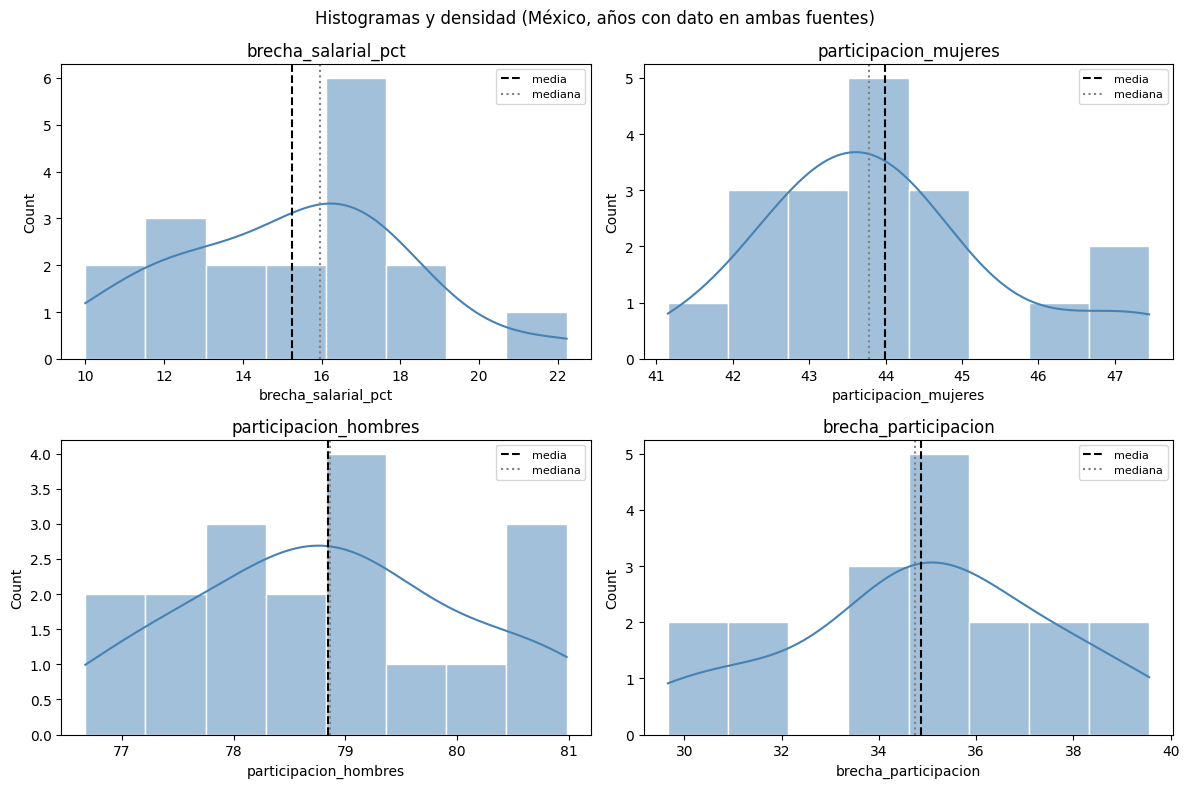

Asimetría y curtosis (respecto a una normal: asimetría 0, curtosis 0):
- brecha_salarial_pct: asimetría=0.22 (casi simétrica); curtosis=-0.16 (colas parecidas a la normal)
- participacion_mujeres: asimetría=0.74 (sesgada a la derecha); curtosis=0.24 (colas parecidas a la normal)
- participacion_hombres: asimetría=0.09 (casi simétrica); curtosis=-0.84 (colas más ligeras)
- brecha_participacion: asimetría=-0.26 (casi simétrica); curtosis=-0.55 (colas más ligeras)


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), numericas_mx[:4]):
    sns.histplot(df_mx[col], bins=8, kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.axvline(df_mx[col].mean(), color='black', linestyle='--', label='media')
    ax.axvline(df_mx[col].median(), color='gray', linestyle=':', label='mediana')
    ax.set_title(col)
    ax.legend(fontsize=8)

fig.suptitle('Histogramas y densidad (México, años con dato en ambas fuentes)')
plt.tight_layout()
plt.show()

print('Asimetría y curtosis (respecto a una normal: asimetría 0, curtosis 0):')
for col in numericas_mx[:4]:
    a = stats.skew(df_mx[col].dropna())
    k = stats.kurtosis(df_mx[col].dropna())
    sim = 'casi simétrica' if abs(a) < 0.5 else ('sesgada a la derecha' if a > 0 else 'sesgada a la izquierda')
    colas = 'colas parecidas a la normal' if abs(k) < 0.5 else ('colas más pesadas' if k > 0 else 'colas más ligeras')
    print(f'- {col}: asimetría={a:.2f} ({sim}); curtosis={k:.2f} ({colas})')

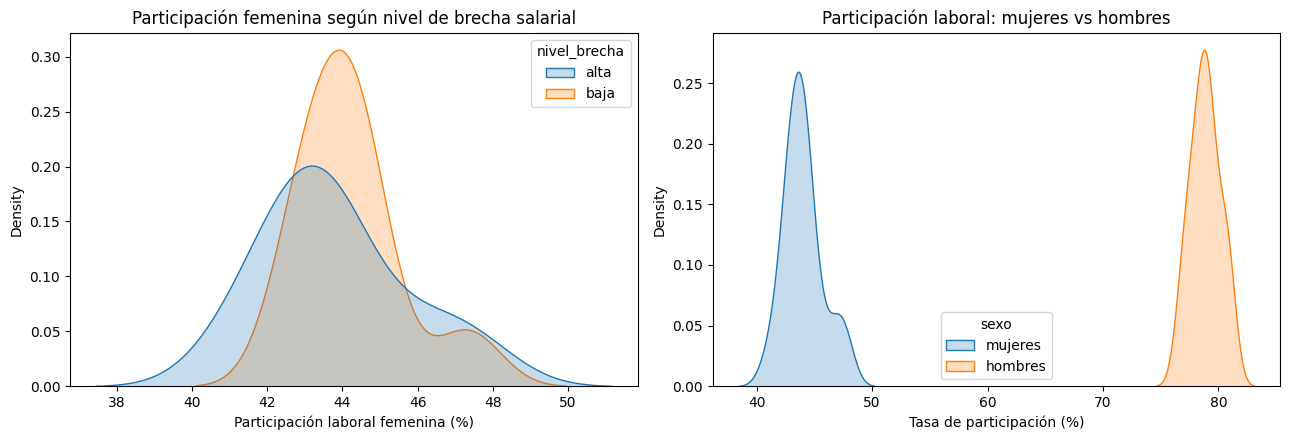

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(
    data=df_mx, x='participacion_mujeres', hue='nivel_brecha',
    fill=True, common_norm=False, ax=axes[0],
)
axes[0].set_title('Participación femenina según nivel de brecha salarial')
axes[0].set_xlabel('Participación laboral femenina (%)')

df_long = df_mx.melt(
    id_vars=['anio'],
    value_vars=['participacion_mujeres', 'participacion_hombres'],
    var_name='sexo', value_name='participacion',
)
df_long['sexo'] = df_long['sexo'].str.replace('participacion_', '')
sns.kdeplot(
    data=df_long, x='participacion', hue='sexo',
    fill=True, common_norm=False, ax=axes[1],
)
axes[1].set_title('Participación laboral: mujeres vs hombres')
axes[1].set_xlabel('Tasa de participación (%)')

plt.tight_layout()
plt.show()

**Qué se ve.** Hay pocos años, así que el histograma de la brecha no sale muy suave. El pico de 2008 suele ser el año más raro. En participación laboral sí hay una diferencia clara: los hombres participan más que las mujeres, de forma estable (va con H2).

---

# Módulo 3. Variables categóricas y análisis multivariable

Hasta ahora vi números sueltos. Ahora miro las columnas que son grupos y las cruzo con los números.

**Categorías:** `nivel_brecha` (alta o baja) y `decada` (2000s, 2010s, 2020s).

**Cruces:**
1. Década y nivel de brecha: ¿los años “altos” se amontonan en algún periodo?
2. Participación de las mujeres y nivel de brecha.
3. Brecha salarial y década.

--- tabla de contingencia: década × nivel de brecha ---
nivel_brecha  alta  baja  All
decada                       
2000s            4     1    5
2010s            3     6    9
2020s            2     2    4
All              9     9   18

proporciones por fila:
nivel_brecha  alta  baja
decada                  
2000s         0.80  0.20
2010s         0.33  0.67
2020s         0.50  0.50


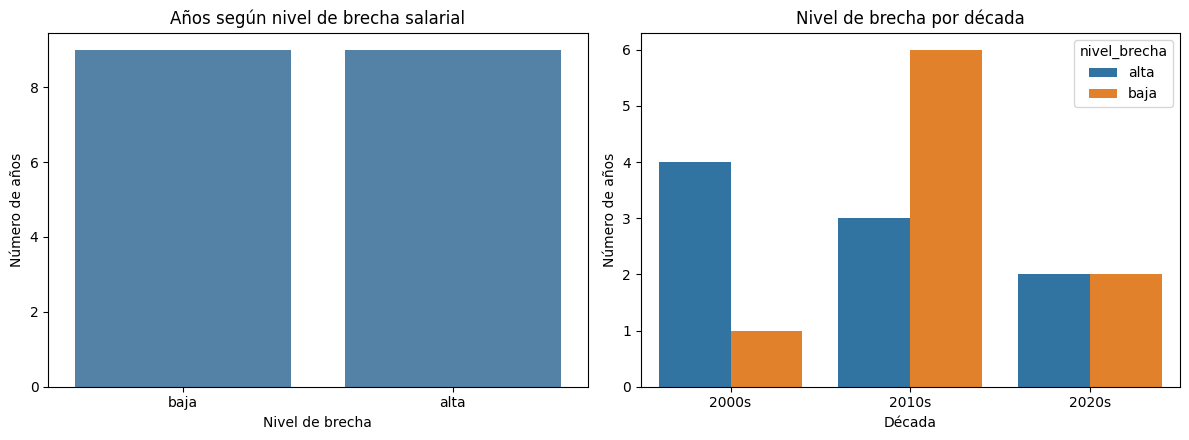

In [26]:
print('--- tabla de contingencia: década × nivel de brecha ---')
contingencia = pd.crosstab(df_mx['decada'], df_mx['nivel_brecha'], margins=True)
print(contingencia)
print()
print('proporciones por fila:')
print(pd.crosstab(df_mx['decada'], df_mx['nivel_brecha'], normalize='index').round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df_mx, x='nivel_brecha', order=['baja', 'alta'], ax=axes[0], color='steelblue')
axes[0].set_title('Años según nivel de brecha salarial')
axes[0].set_xlabel('Nivel de brecha')
axes[0].set_ylabel('Número de años')

sns.countplot(data=df_mx, x='decada', hue='nivel_brecha', ax=axes[1])
axes[1].set_title('Nivel de brecha por década')
axes[1].set_xlabel('Década')
axes[1].set_ylabel('Número de años')
plt.tight_layout()
plt.show()

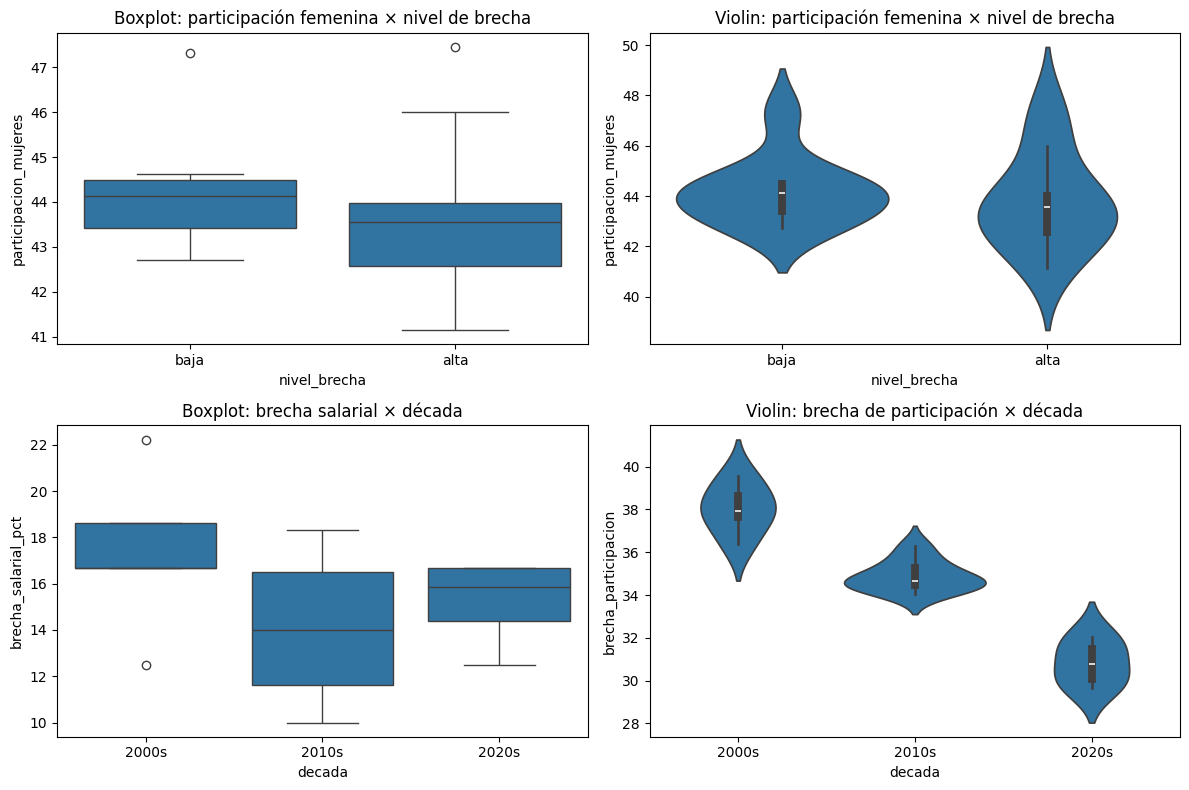

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df_mx, x='nivel_brecha', y='participacion_mujeres', order=['baja', 'alta'], ax=axes[0, 0])
axes[0, 0].set_title('Boxplot: participación femenina × nivel de brecha')

sns.violinplot(data=df_mx, x='nivel_brecha', y='participacion_mujeres', order=['baja', 'alta'], inner='box', ax=axes[0, 1])
axes[0, 1].set_title('Violin: participación femenina × nivel de brecha')

sns.boxplot(data=df_mx, x='decada', y='brecha_salarial_pct', ax=axes[1, 0])
axes[1, 0].set_title('Boxplot: brecha salarial × década')

sns.violinplot(data=df_mx, x='decada', y='brecha_participacion', inner='box', ax=axes[1, 1])
axes[1, 1].set_title('Violin: brecha de participación × década')

plt.tight_layout()
plt.show()

**Qué se ve.** El corte alta/baja parte los años casi a la mitad, porque usa la mediana. Si una década tiene más años “altos”, la brecha no bajó de forma constante (apoya H1). Si las cajas de participación se solapan, cuántas mujeres trabajan no cambia mucho aunque el salario relativo sí lo haga (apunta a H2).

---

# Módulo 4. Correlación, valores atípicos y regresión lineal

Aquí miro si dos cantidades se mueven juntas. Con unos 18 años de México, ajustar una recta es frágil: lo hago para practicar el procedimiento. Si el conjunto de todos los países se descargó bien, lo uso como contraste.

matriz de correlaciones (Pearson):
                        anio  brecha_salarial_pct  participacion_mujeres  \
anio                   1.000               -0.139                  0.909   
brecha_salarial_pct   -0.139                1.000                 -0.073   
participacion_mujeres  0.909               -0.073                  1.000   
participacion_hombres -0.960                0.241                 -0.817   
brecha_participacion  -0.977                0.153                 -0.965   

                       participacion_hombres  brecha_participacion  
anio                                  -0.960                -0.977  
brecha_salarial_pct                    0.241                 0.153  
participacion_mujeres                 -0.817                -0.965  
participacion_hombres                  1.000                 0.940  
brecha_participacion                   0.940                 1.000  


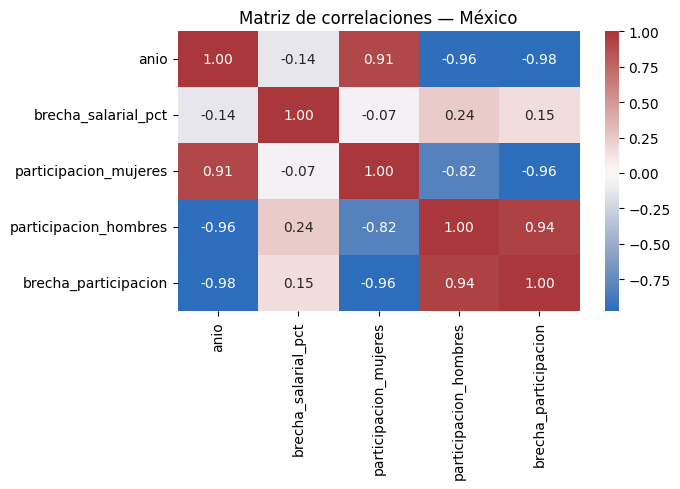

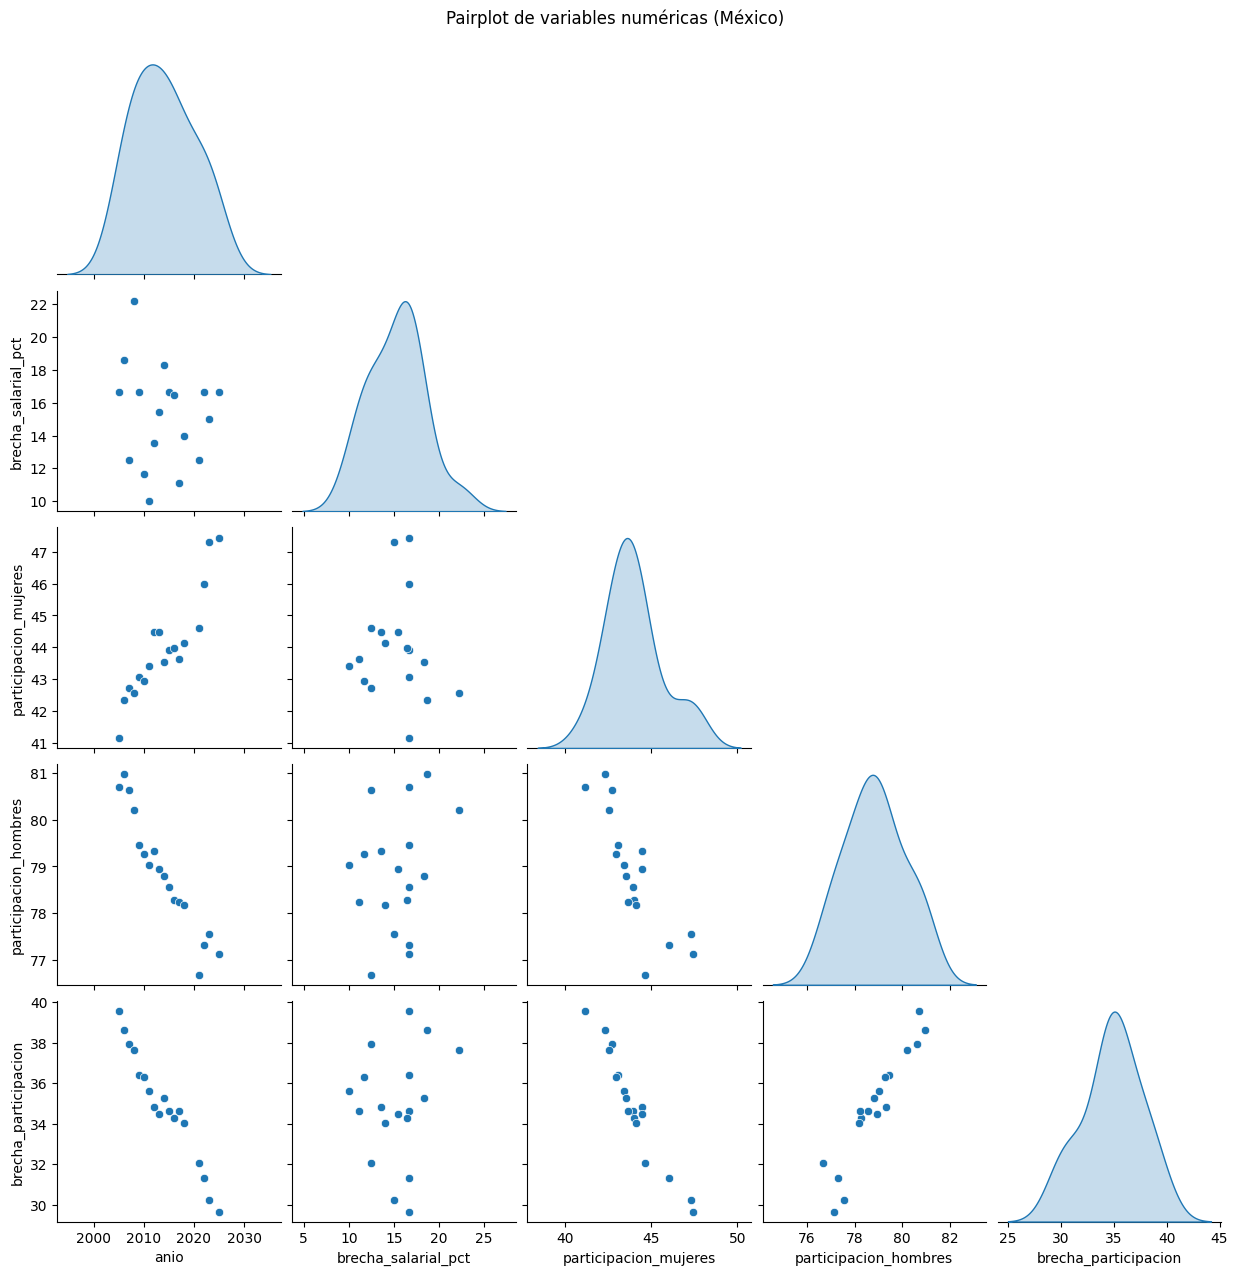

In [28]:
cols_corr = ['anio', 'brecha_salarial_pct', 'participacion_mujeres', 'participacion_hombres', 'brecha_participacion']
print('matriz de correlaciones (Pearson):')
print(df_mx[cols_corr].corr().round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_mx[cols_corr].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Matriz de correlaciones — México')
plt.tight_layout()
plt.show()

sns.pairplot(df_mx[cols_corr], diag_kind='kde', corner=True)
plt.suptitle('Pairplot de variables numéricas (México)', y=1.02)
plt.show()

años con |z| > 2 (candidatos a atípico en la brecha):
   anio  brecha_salarial_pct  z_score
3  2008            22.222222     2.28

IQR: Q1=12.76, Q3=16.67, IQR=3.90, límites [6.91, 22.52]
años fuera de 1.5·IQR:
ninguno


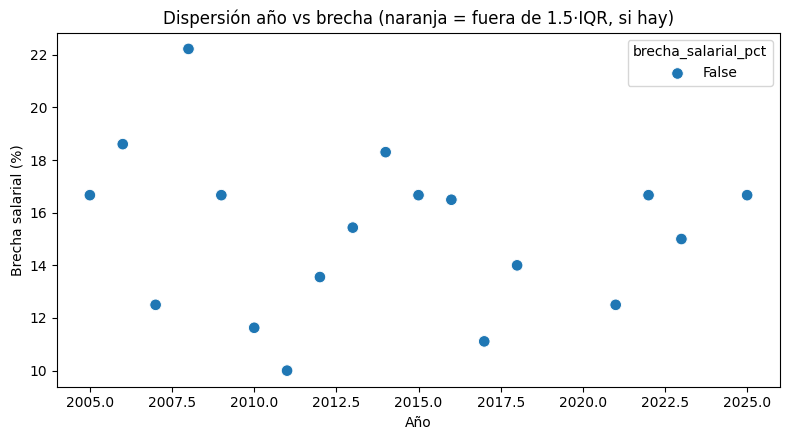


correlaciones con todos los años:
                        anio  brecha_salarial_pct  participacion_mujeres  \
anio                   1.000               -0.139                  0.909   
brecha_salarial_pct   -0.139                1.000                 -0.073   
participacion_mujeres  0.909               -0.073                  1.000   
participacion_hombres -0.960                0.241                 -0.817   
brecha_participacion  -0.977                0.153                 -0.965   

                       participacion_hombres  brecha_participacion  
anio                                  -0.960                -0.977  
brecha_salarial_pct                    0.241                 0.153  
participacion_mujeres                 -0.817                -0.965  
participacion_hombres                  1.000                 0.940  
brecha_participacion                   0.940                 1.000  

correlaciones sin atípicos IQR:
                        anio  brecha_salarial_pct  participac

In [29]:
print('años con |z| > 2 (candidatos a atípico en la brecha):')
atipicos = df_mx.loc[df_mx['z_score'].abs() > 2, ['anio', 'brecha_salarial_pct', 'z_score']]
print(atipicos if not atipicos.empty else 'ninguno')

q1, q3 = df_mx['brecha_salarial_pct'].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask_iqr = (df_mx['brecha_salarial_pct'] < lim_inf) | (df_mx['brecha_salarial_pct'] > lim_sup)
print(f'\nIQR: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, límites [{lim_inf:.2f}, {lim_sup:.2f}]')
print('años fuera de 1.5·IQR:')
print(df_mx.loc[mask_iqr, ['anio', 'brecha_salarial_pct']] if mask_iqr.any() else 'ninguno')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(data=df_mx, x='anio', y='brecha_salarial_pct', hue=mask_iqr, ax=ax, s=70)
ax.set_title('Dispersión año vs brecha (naranja = fuera de 1.5·IQR, si hay)')
ax.set_xlabel('Año')
ax.set_ylabel('Brecha salarial (%)')
plt.tight_layout()
plt.show()

df_sin_atipicos = df_mx.loc[~mask_iqr, cols_corr]
print('\ncorrelaciones con todos los años:')
print(df_mx[cols_corr].corr().round(3))
print('\ncorrelaciones sin atípicos IQR:')
print(df_sin_atipicos.corr().round(3))
print('\nNo elimino puntos: n es pequeño y 2008 es un dato real de la OCDE, no un error de captura.')

brecha_salarial_pct ~ anio: intercepto=155.6290, pendiente=-0.0697, R²=0.019, RMSE=2.936
brecha_salarial_pct ~ participacion_mujeres: intercepto=21.2394, pendiente=-0.1359, R²=0.005, RMSE=2.957


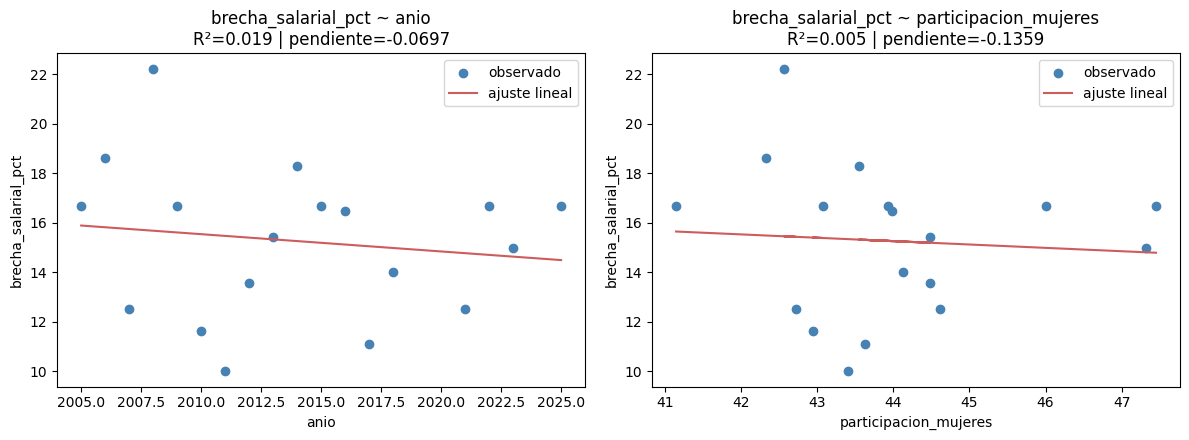


contraste con todos los países de la OCDE (serie Median):
brecha_salarial_pct ~ anio: intercepto=647.6440, pendiente=-0.3146, R²=0.086, RMSE=7.383


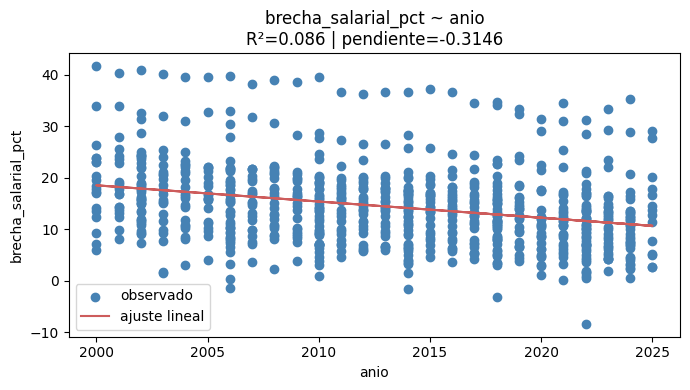

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


def ajustar_regresion(df, x_col, y_col, ax):
    d = df[[x_col, y_col]].dropna()
    X = d[[x_col]].values
    y = d[y_col].values
    modelo = LinearRegression().fit(X, y)
    y_hat = modelo.predict(X)
    ax.scatter(d[x_col], y, color='steelblue', label='observado')
    ax.plot(d[x_col], y_hat, color='indianred', label='ajuste lineal')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} ~ {x_col}\nR²={r2_score(y, y_hat):.3f} | pendiente={modelo.coef_[0]:.4f}')
    ax.legend()
    print(f'{y_col} ~ {x_col}: intercepto={modelo.intercept_:.4f}, pendiente={modelo.coef_[0]:.4f}, '
          f'R²={r2_score(y, y_hat):.3f}, RMSE={np.sqrt(mean_squared_error(y, y_hat)):.3f}')
    return modelo

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
m1 = ajustar_regresion(df_mx, 'anio', 'brecha_salarial_pct', axes[0])
m2 = ajustar_regresion(df_mx, 'participacion_mujeres', 'brecha_salarial_pct', axes[1])
plt.tight_layout()
plt.show()

if 'df_oecd_all' in globals() and df_oecd_all is not None and len(df_oecd_all) > 30:
    print('\ncontraste con todos los países de la OCDE (serie Median):')
    fig, ax = plt.subplots(figsize=(7, 4))
    ajustar_regresion(df_oecd_all, 'anio', 'brecha_salarial_pct', ax)
    plt.tight_layout()
    plt.show()

**Qué se ve.** Si la recta de la brecha contra el año sale casi plana y explica poco, H1 se sostiene: no hay una caída clara. Si la relación con la participación femenina también es débil, H2 también: el salario relativo y cuántas mujeres trabajan no van de la mano. Si 2008 aparece como año raro, no lo borro: es un dato oficial.

---

# Módulo 5. Bootstrap e incertidumbre del modelo

La media de la brecha en México sale de pocos años. Para no fiarme de un solo número, vuelvo a tomar muchas muestras al azar de esos mismos datos (con reemplazo) y miro cómo cambia la media. Eso se llama bootstrap. El intervalo que cubre el 95% de esas medias dice en qué rango es razonable colocar el promedio.

Después pruebo la recta partiendo los datos: una parte para entrenar y otra para comprobar, y también validación cruzada. Con 18 filas eso es inestable; si puedo, lo repito con todos los países de la OCDE.

media observada: 15.260%
error estándar bootstrap: 0.697
IC 95% percentil: [13.906, 16.666]
asimetría de la distribución muestral: 0.065
curtosis de la distribución muestral: -0.038


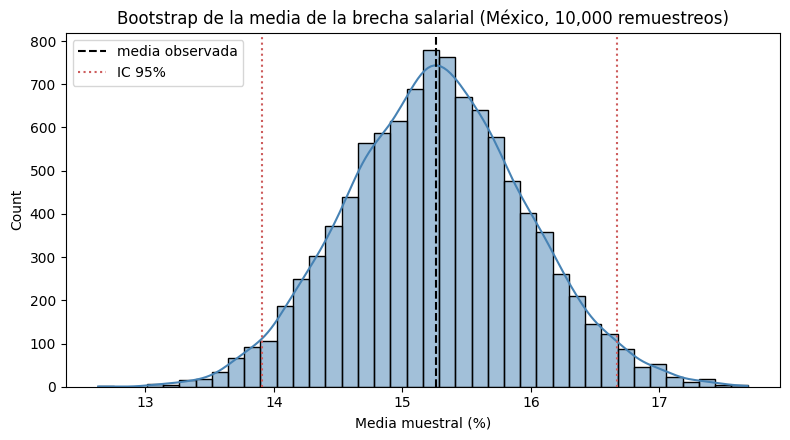

In [31]:
np.random.seed(42)
serie = df_mx['brecha_salarial_pct'].dropna().to_numpy()
n_boot = 10_000
muestras = np.random.choice(serie, size=(n_boot, len(serie)), replace=True)
medias_boot = muestras.mean(axis=1)

ee = medias_boot.std(ddof=1)
ic_low, ic_high = np.percentile(medias_boot, [2.5, 97.5])
asimetria_boot = stats.skew(medias_boot)
curtosis_boot = stats.kurtosis(medias_boot)

print(f'media observada: {serie.mean():.3f}%')
print(f'error estándar bootstrap: {ee:.3f}')
print(f'IC 95% percentil: [{ic_low:.3f}, {ic_high:.3f}]')
print(f'asimetría de la distribución muestral: {asimetria_boot:.3f}')
print(f'curtosis de la distribución muestral: {curtosis_boot:.3f}')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(medias_boot, bins=40, kde=True, ax=ax, color='steelblue')
ax.axvline(serie.mean(), color='black', linestyle='--', label='media observada')
ax.axvline(ic_low, color='indianred', linestyle=':', label='IC 95%')
ax.axvline(ic_high, color='indianred', linestyle=':')
ax.set_title('Bootstrap de la media de la brecha salarial (México, 10,000 remuestreos)')
ax.set_xlabel('Media muestral (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split

X = df_mx[['anio']].values
y = df_mx['brecha_salarial_pct'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo_split = LinearRegression().fit(X_train, y_train)
print('México, 70% entrenar / 30% comprobar (brecha ~ año):')
print(f'  R² train={modelo_split.score(X_train, y_train):.3f} | R² test={modelo_split.score(X_test, y_test):.3f}')

n_splits = min(5, max(2, len(df_mx)))
cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
scores_mx = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='r2')
print(f'  validación cruzada México: promedio R²={scores_mx.mean():.3f}, variación={scores_mx.std():.3f}')

if 'df_oecd_all' in globals() and df_oecd_all is not None and len(df_oecd_all) > 40:
    d = df_oecd_all[['anio', 'brecha_salarial_pct']].dropna()
    Xp, yp = d[['anio']].values, d['brecha_salarial_pct'].values
    Xp_train, Xp_test, yp_train, yp_test = train_test_split(Xp, yp, test_size=0.3, random_state=42)
    modelo_panel = LinearRegression().fit(Xp_train, yp_train)
    print('\nTodos los países OCDE, 70% entrenar / 30% comprobar (brecha ~ año):')
    print(f'  R² train={modelo_panel.score(Xp_train, yp_train):.3f} | R² test={modelo_panel.score(Xp_test, yp_test):.3f}')
    scores_panel = cross_val_score(
        LinearRegression(), Xp, yp,
        cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2',
    )
    print(f'  validación cruzada panel: promedio R²={scores_panel.mean():.3f}, variación={scores_panel.std():.3f}')

México, 70% entrenar / 30% comprobar (brecha ~ año):
  R² train=0.062 | R² test=-0.689
  validación cruzada México: promedio R²=-0.631, variación=0.458

Todos los países OCDE, 70% entrenar / 30% comprobar (brecha ~ año):
  R² train=0.104 | R² test=0.045
  validación cruzada panel: promedio R²=0.077, variación=0.039


**Qué se ve.** El histograma de las medias repetidas suele verse más suave que la serie original. Un intervalo ancho avisa de que no conviene hablar de “la” brecha típica como si fuera un número exacto. El R² al comprobar casi seguro sale peor que al entrenar: con pocos años el modelo no generaliza.

---

# Módulo 6. Gráficas avanzadas

Estas figuras piden más de un país. Por eso conservé `df_oecd_all` desde la consulta de la OCDE (ya se descargaba el dataset completo). No invento números.

- **Treemap:** cada recuadro es un país; tamaño y color muestran la brecha del último año con dato.
- **Scatter:** año contra brecha, color según la región.
- **Hexágonos:** dónde se amontonan los puntos cuando hay miles de filas.
- **Mapa:** la brecha del último año en cada país.
- **Barras apiladas:** cuántos países quedan con brecha baja, media o alta en cada año.

In [33]:
REGIONES = {
    'MEX': 'América', 'USA': 'América', 'CAN': 'América', 'CHL': 'América',
    'COL': 'América', 'CRI': 'América', 'BRA': 'América', 'ARG': 'América',
    'DEU': 'Europa', 'FRA': 'Europa', 'ESP': 'Europa', 'ITA': 'Europa',
    'GBR': 'Europa', 'SWE': 'Europa', 'NOR': 'Europa', 'DNK': 'Europa',
    'FIN': 'Europa', 'NLD': 'Europa', 'BEL': 'Europa', 'AUT': 'Europa',
    'CHE': 'Europa', 'POL': 'Europa', 'CZE': 'Europa', 'HUN': 'Europa',
    'PRT': 'Europa', 'GRC': 'Europa', 'IRL': 'Europa', 'ISL': 'Europa',
    'LUX': 'Europa', 'SVK': 'Europa', 'SVN': 'Europa', 'EST': 'Europa',
    'LVA': 'Europa', 'LTU': 'Europa', 'TUR': 'Europa',
    'JPN': 'Asia-Pacífico', 'KOR': 'Asia-Pacífico', 'AUS': 'Asia-Pacífico',
    'NZL': 'Asia-Pacífico', 'ISR': 'Asia-Pacífico',
}

if 'df_oecd_all' not in globals() or df_oecd_all is None or len(df_oecd_all) == 0:
    print('No está el conjunto de todos los países. Vuelve a correr la consulta de la OCDE.')
    df_panel = pd.DataFrame(columns=['pais', 'pais_nombre', 'anio', 'brecha_salarial_pct', 'region'])
    df_ultimo = df_panel.copy()
else:
    df_panel = df_oecd_all.copy()
    if 'pais_nombre' not in df_panel.columns:
        df_panel['pais_nombre'] = df_panel['pais']
    df_panel['region'] = df_panel['pais'].map(REGIONES).fillna('Otro')
    df_ultimo = df_panel.sort_values('anio').groupby('pais', as_index=False).tail(1).copy()
    print('filas de todos los países:', df_panel.shape[0], '| países con último año:', df_ultimo.shape[0])
    print(df_panel['region'].value_counts())

filas de todos los países: 784 | países con último año: 50
region
Europa           394
América          137
Asia-Pacífico    127
Otro             126
Name: count, dtype: int64


In [34]:
import plotly.express as px

if df_panel.empty:
    print('Sin datos de países para el treemap y el gráfico de puntos.')
else:
    fig_tree = px.treemap(
        df_ultimo,
        path=['region', 'pais_nombre'],
        values='brecha_salarial_pct',
        color='brecha_salarial_pct',
        color_continuous_scale='RdBu_r',
        title='Treemap: brecha salarial (mediana) en el último año disponible, OCDE',
    )
    fig_tree.update_layout(margin=dict(t=50, l=10, r=10, b=10))
    fig_tree.show()

    fig_sc = px.scatter(
        df_panel, x='anio', y='brecha_salarial_pct', color='region',
        hover_name='pais_nombre', opacity=0.7,
        title='Año contra brecha salarial, color según la región',
        labels={'anio': 'Año', 'brecha_salarial_pct': 'Brecha salarial (%)', 'region': 'Región'},
    )
    fig_sc.show()

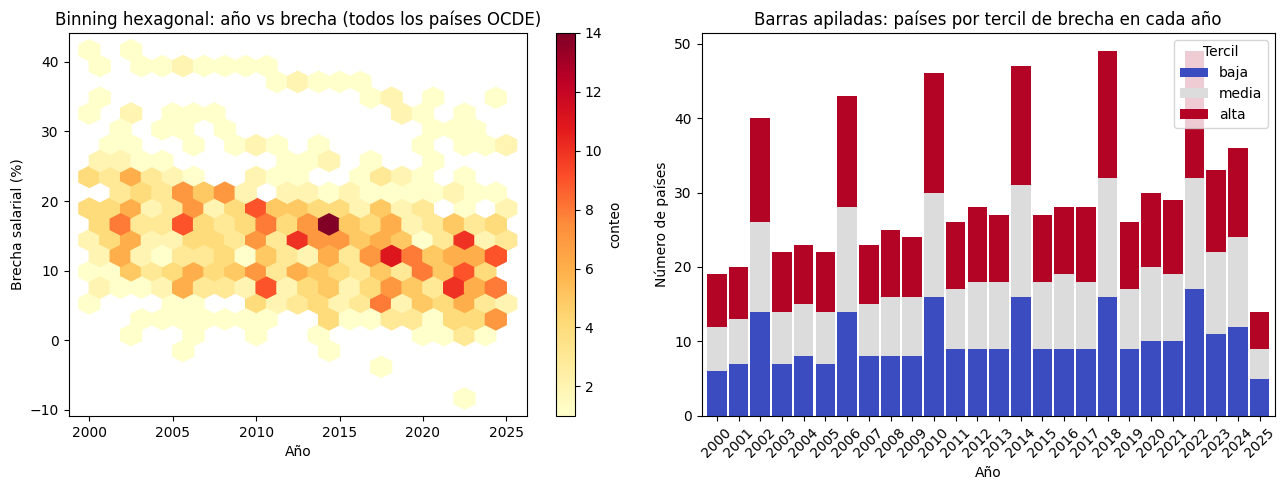

In [35]:
if df_panel.empty:
    print('Sin datos de países para hexágonos, barras apiladas o mapa.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    hb = axes[0].hexbin(df_panel['anio'], df_panel['brecha_salarial_pct'], gridsize=20, cmap='YlOrRd', mincnt=1)
    axes[0].set_title('Binning hexagonal: año vs brecha (todos los países OCDE)')
    axes[0].set_xlabel('Año')
    axes[0].set_ylabel('Brecha salarial (%)')
    fig.colorbar(hb, ax=axes[0], label='conteo')

    def tercil_del_anio(s):
        s = pd.to_numeric(s, errors='coerce')
        if s.nunique(dropna=True) < 3:
            return pd.Series(np.where(s.isna(), np.nan, 'media'), index=s.index)
        try:
            return pd.qcut(s, 3, labels=['baja', 'media', 'alta'], duplicates='drop')
        except ValueError:
            return pd.Series(np.where(s.isna(), np.nan, 'media'), index=s.index)

    df_panel['tercil'] = df_panel.groupby('anio')['brecha_salarial_pct'].transform(tercil_del_anio)
    apilado = df_panel.dropna(subset=['tercil']).groupby(['anio', 'tercil'], observed=False).size().unstack(fill_value=0)
    apilado.plot(kind='bar', stacked=True, ax=axes[1], width=0.9, colormap='coolwarm')
    axes[1].set_title('Barras apiladas: países por tercil de brecha en cada año')
    axes[1].set_xlabel('Año')
    axes[1].set_ylabel('Número de países')
    axes[1].legend(title='Tercil')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    fig_map = px.choropleth(
        df_ultimo,
        locations='pais',
        color='brecha_salarial_pct',
        hover_name='pais_nombre',
        color_continuous_scale='RdBu_r',
        title='Mapa: brecha salarial de género (último año OCDE)',
        labels={'brecha_salarial_pct': 'Brecha (%)', 'pais': 'ISO-3'},
    )
    fig_map.update_layout(margin=dict(t=50, l=0, r=0, b=0))
    fig_map.show()

**Qué se ve.** El treemap y el mapa ponen a México en contexto. Los hexágonos muestran dónde se concentran los datos de la OCDE. Las barras apiladas resumen si, con el tiempo, hay más países en el grupo de brecha baja.

---

# Módulo 7. Procesamiento de lenguaje natural

Las tablas de la OCDE y del Banco Mundial no traen texto libre. Voy a trabajar el artículo de Wikipedia sobre brecha salarial de género. Si no se puede descargar, uso un texto de respaldo. También limpio con expresiones regulares los nombres de país.

Uso NLTK para contar palabras, ver en qué frases aparecen y hacer un análisis de tono del texto en inglés. SpaCy es opcional: si no está instalado, NLTK alcanza para esta práctica.

In [36]:
CORPUS_RESPALDO_ES = """
La brecha salarial de género es la diferencia entre los ingresos de hombres y mujeres.
La OCDE la reporta con la mediana de salarios de trabajadores a tiempo completo.
En México la brecha no ha desaparecido pese a reformas de igualdad laboral.
La participación de las mujeres en el mercado de trabajo sigue por debajo de la de los hombres.
Organismos como el Banco Mundial, INEGI e INMUJERES publican indicadores de ocupación y salarios.
Una menor brecha salarial no implica por sí sola más mujeres empleadas.
Los factores incluyen segregación ocupacional, horas trabajadas, interrupciones de carrera y discriminación.
"""

CORPUS_RESPALDO_EN = """
The gender wage gap is the difference between median earnings of men and women.
The OECD publishes a headline median gap for full-time employees.
Mexico still reports a positive gap, meaning men earn more than women at the median.
Female labour force participation remains lower than male participation.
A stable wage gap together with a stable participation gap supports the idea that pay and employment follow different paths.
Keywords: wages, women, men, median, inequality, employment, discrimination, occupation.
"""


def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'\[[0-9]+\]', ' ', texto)
    texto = re.sub(r'[^a-záéíóúüñàèìòùäëïöüç\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def wikipedia_extracto(titulo, lang='es'):
    try:
        r = requests.get(
            f'https://{lang}.wikipedia.org/w/api.php',
            params={'action': 'query', 'prop': 'extracts', 'explaintext': True,
                    'titles': titulo, 'format': 'json'},
            headers={'User-Agent': 'BrechaSalarialProyectoEscolar/1.0 (practica-data-science)'},
            timeout=20,
        )
        r.raise_for_status()
        pages = r.json()['query']['pages']
        extracto = next(iter(pages.values())).get('extract', '')
        return extracto if extracto and len(extracto) > 200 else None
    except Exception as e:
        print('no se pudo bajar Wikipedia:', e)
        return None


texto_es = wikipedia_extracto('Brecha salarial de género', 'es') or CORPUS_RESPALDO_ES
texto_en = wikipedia_extracto('Gender pay gap', 'en') or CORPUS_RESPALDO_EN
print('caracteres ES:', len(texto_es), '| EN:', len(texto_en))

if 'df_oecd_all' in globals() and df_oecd_all is not None and 'pais_nombre' in df_oecd_all.columns:
    nombres = df_oecd_all['pais_nombre'].dropna().astype(str).drop_duplicates()
    nombres_limpios = nombres.apply(lambda s: re.sub(r'\s+', ' ', re.sub(r'[^A-Za-zÁÉÍÓÚáéíóúñÑ ]', '', s)).strip())
    print('ejemplo regex en nombres de país:', list(zip(nombres.head(5), nombres_limpios.head(5))))

caracteres ES: 31521 | EN: 68212
ejemplo regex en nombres de país: [('Argentina', 'Argentina'), ('Australia', 'Australia'), ('Austria', 'Austria'), ('Belgium', 'Belgium'), ('Bulgaria', 'Bulgaria')]


In [37]:
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.probability import FreqDist
from nltk.util import bigrams
from nltk.text import Text

for recurso in ['punkt', 'stopwords', 'vader_lexicon']:
    try:
        nltk.download(recurso, quiet=True)
    except Exception:
        pass
try:
    nltk.download('punkt_tab', quiet=True)
except Exception:
    pass

try:
    stop_es = set(stopwords.words('spanish')) | {'si', 'ser', 'the'}
except Exception:
    stop_es = {'el', 'la', 'los', 'las', 'de', 'en', 'y', 'a', 'un', 'una', 'que', 'se', 'si', 'ser', 'the', 'del', 'por', 'con'}

tokens_es = [t for t in word_tokenize(limpiar_texto(texto_es)) if t not in stop_es and len(t) > 2]
texto_nltk = Text(tokens_es)

print('contextos de "brecha":')
try:
    texto_nltk.concordance('brecha', width=80, lines=8)
except Exception:
    print('la palabra no aparece suficiente en el corpus')

print('\npalabras en contextos similares a semillas del tema:')
vocab = set(tokens_es)
for semilla in ['mujeres', 'salario', 'brecha', 'igualdad']:
    if semilla in vocab:
        print('---', semilla, '---')
        texto_nltk.similar(semilla)
    else:
        print(semilla, 'no aparece en el corpus tokenizado')

freq = FreqDist(tokens_es)
print('\ntop 15 palabras:', freq.most_common(15))
bigramas = FreqDist([' '.join(b) for b in bigrams(tokens_es)])
print('top 10 bigramas:', bigramas.most_common(10))

contextos de "brecha":
Displaying 8 of 59 matches:
                                     brecha salarial género conocida diferencia 
acuerdo ocde comisión europea define brecha salarial género diferencia relativa 
uestos mayor responsabilidad estatus brecha salarial ajustada ajustada important
abajo ejemplo sector actividad parte brecha salarial ajustada puede atribuirse h
 deben opciones personales denominan brecha salarial ajustada interpretan discri
ducen permanencia empleo diferencias brecha salarial europa situaba eurostat apr
llegó conclusión principales razones brecha salarial relacionadas frecuentemente
mujeres ganan promedio menos varones brecha género respecto ingresos oscila hung

palabras en contextos similares a semillas del tema:
--- mujeres ---
hombres menos bajas alto
--- salario ---

--- brecha ---
diferencia
--- igualdad ---


top 15 palabras: [('mujeres', 92), ('género', 66), ('brecha', 59), ('salarial', 56), ('trabajo', 51), ('hombres', 48), ('promedio', 23), ('difer

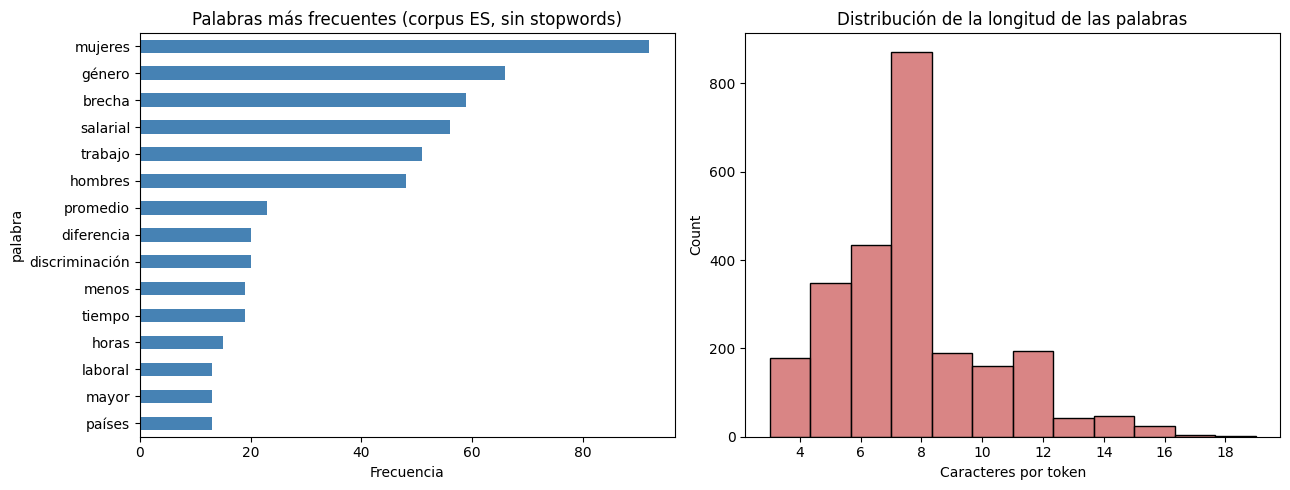

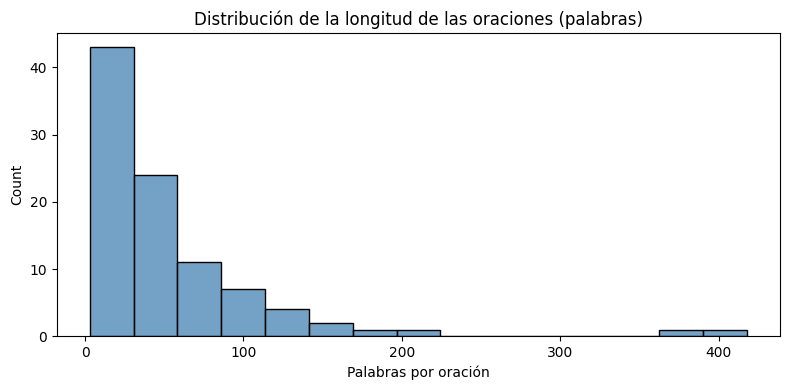

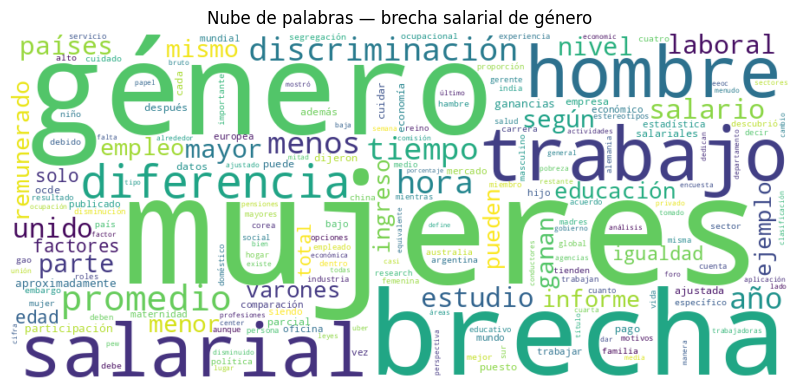

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pd.DataFrame(freq.most_common(15), columns=['palabra', 'n']).plot.barh(x='palabra', y='n', ax=axes[0], color='steelblue', legend=False)
axes[0].invert_yaxis()
axes[0].set_title('Palabras más frecuentes (corpus ES, sin stopwords)')
axes[0].set_xlabel('Frecuencia')

longitudes = [len(t) for t in tokens_es]
sns.histplot(longitudes, bins=12, ax=axes[1], color='indianred')
axes[1].set_title('Distribución de la longitud de las palabras')
axes[1].set_xlabel('Caracteres por token')
plt.tight_layout()
plt.show()

try:
    oraciones = sent_tokenize(texto_es, language='spanish')
except Exception:
    oraciones = sent_tokenize(texto_es)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot([len(o.split()) for o in oraciones], bins=15, ax=ax, color='steelblue')
ax.set_title('Distribución de la longitud de las oraciones (palabras)')
ax.set_xlabel('Palabras por oración')
plt.tight_layout()
plt.show()

from wordcloud import WordCloud
if tokens_es:
    wc = WordCloud(width=900, height=400, background_color='white', collocations=False).generate(' '.join(tokens_es))
    plt.figure(figsize=(11, 4.5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nube de palabras — brecha salarial de género')
    plt.show()
else:
    print('No hay suficientes palabras para armar la nube.')

                    count   mean  median
segmento                                
resto del artículo    454  0.003     0.0


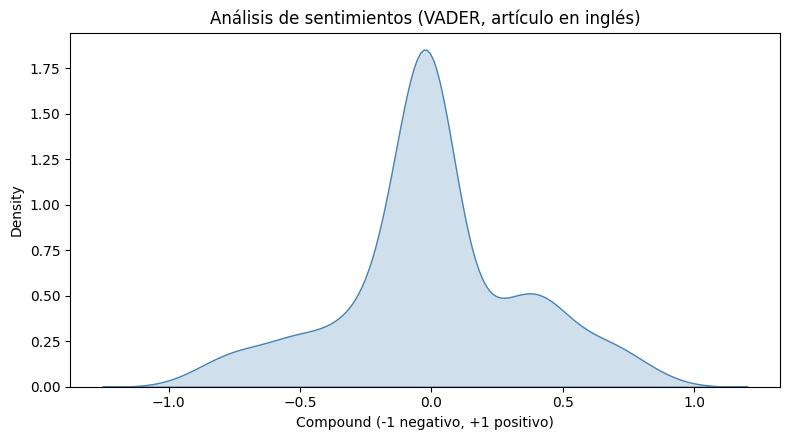

SpaCy disponible; tokens de muestra: ['la', 'brecha', 'salarial', 'de', 'género', 'también', 'conocida', 'como', 'diferencia', 'salarial', 'de', 'género']


In [39]:
sia = SentimentIntensityAnalyzer()
try:
    oraciones_en = sent_tokenize(texto_en, language='english')
except Exception:
    oraciones_en = sent_tokenize(texto_en)
polaridades = [sia.polarity_scores(o)['compound'] for o in oraciones_en]
df_sent = pd.DataFrame({'oracion': oraciones_en, 'compound': polaridades})
df_sent['segmento'] = np.where(
    df_sent['oracion'].str.contains(r'mexico|mexican', case=False, regex=True),
    'menciona México',
    'resto del artículo',
)
print(df_sent.groupby('segmento')['compound'].agg(['count', 'mean', 'median']).round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
if df_sent['segmento'].nunique() > 1:
    sns.kdeplot(data=df_sent, x='compound', hue='segmento', fill=True, common_norm=False, ax=ax)
else:
    sns.kdeplot(data=df_sent, x='compound', fill=True, ax=ax, color='steelblue')
ax.set_title('Análisis de sentimientos (VADER, artículo en inglés)')
ax.set_xlabel('Compound (-1 negativo, +1 positivo)')
plt.tight_layout()
plt.show()

try:
    import spacy
    nlp = spacy.blank('es')
    doc = nlp(limpiar_texto(texto_es)[:2000])
    print('SpaCy disponible; tokens de muestra:', [t.text for t in list(doc)[:12]])
except Exception:
    print('SpaCy no está instalado; el análisis se hizo con NLTK.')

**Qué se ve.** Las palabras más repetidas y la nube deberían destacar términos como brecha, salarial, mujeres, hombres y empleo. El tono se calcula sobre el texto en inglés; por eso no lo aplico al español.

---

# Módulo 8. Regresión logística

El proyecto no nació para predecir una etiqueta, pero la práctica pide entrenar un modelo de clasificación y evaluarlo.

**Qué no hago:** predecir si un año de México es de brecha “alta” usando la propia brecha. Eso sería copiar la etiqueta.

**Qué sí hago:** en el conjunto de todos los países, marco cada fila como brecha alta si está por encima de la mediana global. El modelo solo ve el **año** y la **región**.

mediana global de brecha: 13.718
brecha_alta
0    392
1    392
Name: count, dtype: int64
matriz de confusión (filas=real, columnas=predicho):
 [[81 37]
 [38 80]]
exactitud (accuracy): 0.682
precisión: 0.684
sensibilidad (recall): 0.678
especificidad: 0.686
AUC: 0.744


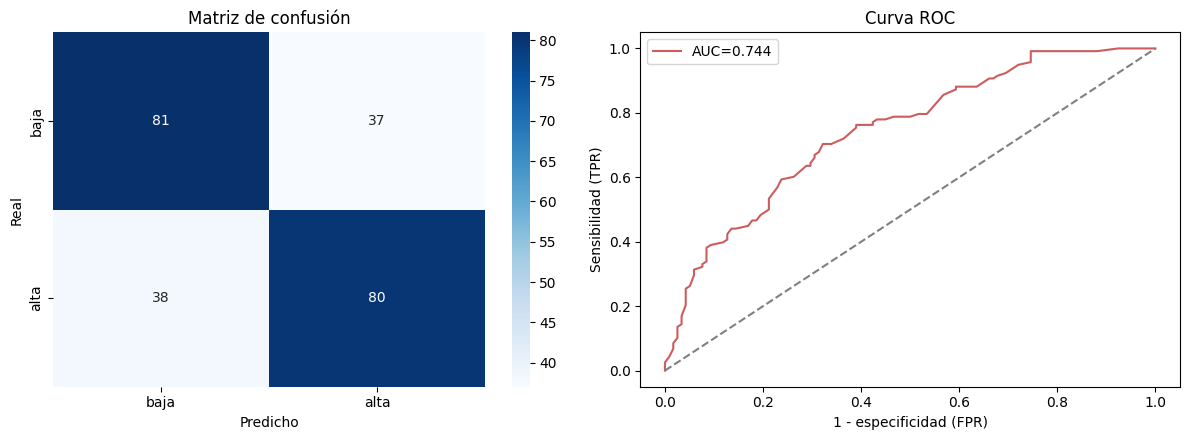

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if df_panel.empty or df_panel['brecha_salarial_pct'].dropna().empty:
    print('No hay datos de países para entrenar el modelo. Vuelve a correr la consulta de la OCDE.')
else:
    mediana_global = df_panel['brecha_salarial_pct'].median()
    df_clf = df_panel.dropna(subset=['brecha_salarial_pct', 'anio', 'region']).copy()
    df_clf['brecha_alta'] = (df_clf['brecha_salarial_pct'] > mediana_global).astype(int)
    print('mediana global de brecha:', round(mediana_global, 3))
    print(df_clf['brecha_alta'].value_counts())

    X_clf = pd.get_dummies(df_clf[['anio', 'region']], drop_first=True).astype(float)
    y_clf = df_clf['brecha_alta']

    if y_clf.nunique() < 2 or len(df_clf) < 10:
        print('Hay muy pocos datos o una sola clase; no entreno el modelo.')
    else:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf,
        )

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        logit = LogisticRegression(max_iter=1000, random_state=42)
        logit.fit(X_tr_s, y_tr)
        y_pred = logit.predict(X_te_s)
        y_prob = logit.predict_proba(X_te_s)[:, 1]

        cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        especificidad = tn / (tn + fp) if (tn + fp) else np.nan
        sensibilidad = recall_score(y_te, y_pred, zero_division=0)

        print('matriz de confusión (filas=real, columnas=predicho):\n', cm)
        print(f'exactitud (accuracy): {accuracy_score(y_te, y_pred):.3f}')
        print(f'precisión: {precision_score(y_te, y_pred, zero_division=0):.3f}')
        print(f'sensibilidad (recall): {sensibilidad:.3f}')
        print(f'especificidad: {especificidad:.3f}')
        print(f'AUC: {roc_auc_score(y_te, y_prob):.3f}')

        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['baja', 'alta'], yticklabels=['baja', 'alta'])
        axes[0].set_title('Matriz de confusión')
        axes[0].set_xlabel('Predicho')
        axes[0].set_ylabel('Real')

        fpr, tpr, _ = roc_curve(y_te, y_prob)
        axes[1].plot(fpr, tpr, color='indianred', label=f'AUC={roc_auc_score(y_te, y_prob):.3f}')
        axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
        axes[1].set_title('Curva ROC')
        axes[1].set_xlabel('1 - especificidad (FPR)')
        axes[1].set_ylabel('Sensibilidad (TPR)')
        axes[1].legend()
        plt.tight_layout()
        plt.show()

**Qué se ve.** La curva ROC y el AUC dicen qué tan bien el modelo distingue brecha alta de baja. Un valor de 0.5 es como lanzar una moneda. Este modelo es un ejercicio; el centro del proyecto sigue siendo describir la brecha en México.

## 12. Conclusiones

La brecha salarial de género (mediana) en México se movió entre 10% y 22% aproximadamente entre 2005 y 2025, sin que se vea una tendencia clara de reducción esto va en línea con H1.

Faltan varios años en la serie (2019, 2020, 2024, entre otros), lo que limita qué tan fino se puede analizar la tendencia año con año.

Falta cruzar esto con participación laboral de forma más rigurosa (por ahora solo está el gráfico comparativo, no un análisis estadístico de correlación).

**Siguientes pasos:**
- Correr una regresión simple para ver si la tendencia es estadísticamente significativa o si el movimiento es solo ruido.
- Agregar más países de la OCDE para tener un punto de comparación, ahora mismo solo hay México.
- Revisar si vale la pena usar las series de Decile 1 / Decile 9 que se dejaron fuera, para ver si la brecha es distinta en la parte baja vs alta de la distribución salarial.
- Si el proyecto sigue creciendo, pasar los datos a una base (Mongo o MySQL) en vez de CSV sueltos.
